<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_10_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [208]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [209]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [210]:
df = pd.read_csv("/content/Audi_A1_listings.csv")
#https://www.kaggle.com/datasets/jacklacey/audi-a1-listings/data - datamızı aldığımız yer.

SÜTUN AÇIKLAMALARI
**kalın metin**
Year (Yıl / Model Yılı): Aracın trafiğe tescil edildiği veya üretildiği yıl.

Type (Kasa Tipi / Tür): Aracın gövde tipi (örneğin; Sedan, Hatchback, SUV vb.).

Mileage(miles) (Kilometre / Mil): Aracın o güne kadar yaptığı toplam yol mesafesi (mil cinsinden).

Engine (Motor Hacmi): Motorun silindir hacmi (litre cinsinden, örn. 1.6L, 2.0L).

PS (Beygir Gücü - Metrik): Pferdestärke teriminin kısaltmasıdır; aracın motor gücünü ifade eder (1 PS, yaklaşık 0,986 İngiliz beygir gücüne - HP'ye eşittir).

Transmission (Şanzıman / Vites Tipi): Aracın vites türü (manuel, otomatik veya yarı otomatik).

Fuel (Yakıt Tipi): Aracın kullandığı yakıt türü (benzin, dizel, hibrit, elektrik vb.).

Number_of_Owners (Önceki Sahip Sayısı): Aracın daha önce kaç farklı kişi veya kurum tarafından sahiplenildiğini gösteren sayı.

Price(£) (Fiyat): Aracın İngiliz sterlini (£) cinsinden satış fiyatı.

href (İlan Bağlantısı): İlgili araç ilanının internet adresi veya web bağlantı linki.

PPY - Price Per Year (Yıllık Maliyet): Aracın Fiyatı / (10 - Aracın Yaşı) formülüyle hesaplanan metrik. Aracı 10 yaşına geldiğinde satmayı planladığınız varsayımıyla, kalan yıllar boyunca aracın size yıllık maliyetini gösterir.

MileageRank (Kilometre Sıralaması): Aracın veri kümesindeki mil sıralaması. Kilometresi daha düşük olan araçlara daha yüksek/iyi bir derece verilir.

PriceRank (Fiyat Sıralaması): Aracın veri kümesindeki fiyat sıralaması. Fiyatı daha ucuz olan araçlara daha yüksek/iyi bir derece verilir.

PPYRank (Yıllık Maliyet Sıralaması): Aracın yıllık maliyetine (PPY) göre veri kümesindeki sırası. Yıllık maliyeti daha düşük olan araçlar daha üst/iyi sırada yer alır.

Score (Toplam Skor / Puan): MileageRank, PriceRank ve PPYRank değerlerinin toplamı. Hem ucuz hem az kullanılmış hem de yıllık maliyeti düşük olan en avantajlı araçları tespit etmek için kullanılan genel bir değerlendirme puanıdır.

In [211]:
df.head() #en tepe 5 indexi getirdi.

,index,Year,Type,Mileage(miles),Engine,PS,Transmission,Fuel,Number_of_Owners,Price(£),href,PPY,MileageRank,PriceRank,PPYRank,Score
0,0,2018.0,Hatchback,44000.0,1.6L,114.398422,Manual,Diesel,1,14995.0,https://www.autotrader.co.uk/car-details/20221...,2499.166667,215,163,340,718
1,4,2016.0,Hatchback,42596.0,1.0L,93.688363,Manual,Petrol,3,10755.0,https://www.autotrader.co.uk/car-details/20221...,2688.750000,222,330,276,828
2,7,2015.0,Hatchback,42700.0,1.4L,123.274162,Manual,Petrol,2,10799.0,https://www.autotrader.co.uk/car-details/20221...,3599.666667,221,327,94,642
3,11,2014.0,Hatchback,86000.0,1.6L,103.550296,Manual,Diesel,3,7490.0,https://www.autotrader.co.uk/car-details/20221...,3745.000000,41,449,83,573
4,12,2014.0,Hatchback,104310.0,1.6L,103.550296,Manual,Diesel,3,7400.0,https://www.autotrader.co.uk/car-details/20220...,3700.000000,12,452,85,549


In [212]:
df.tail() # en alt 5 indexi getirdi.

,index,Year,Type,Mileage(miles),Engine,PS,Transmission,Fuel,Number_of_Owners,Price(£),href,PPY,MileageRank,PriceRank,PPYRank,Score
466,985,2014.0,Hatchback,40195.0,1.4L,138.067061,Automatic,Petrol,3,11275.0,https://www.autotrader.co.uk/car-details/20220...,5637.500000,236,302,12,550
467,986,2020.0,Hatchback,26218.0,1.0L,114.398422,Manual,Petrol,1,18495.0,https://www.autotrader.co.uk/car-details/20221...,2311.875000,342,93,404,839
468,987,2017.0,Hatchback,48571.0,1.4L,123.274162,Manual,Petrol,2,11995.0,https://www.autotrader.co.uk/car-details/20221...,2399.000000,190,257,372,819
469,988,2020.0,Hatchback,9584.0,1.0L,93.688363,Manual,Petrol,1,19970.0,https://www.autotrader.co.uk/car-details/20221...,2496.250000,444,64,346,854
470,990,2019.0,Hatchback,17303.0,1.0L,114.398422,Manual,Petrol,1,17195.0,https://www.autotrader.co.uk/car-details/20221...,2456.428571,399,125,360,884


In [213]:
df.info() #dataframe hakkında genel bilgilendirme. sütunların data tipleri ve sayıları.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471 entries, 0 to 470
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   index             471 non-null    int64  
 1   Year              471 non-null    float64
 2   Type              471 non-null    object 
 3   Mileage(miles)    471 non-null    float64
 4   Engine            471 non-null    object 
 5   PS                471 non-null    float64
 6   Transmission      471 non-null    object 
 7   Fuel              471 non-null    object 
 8   Number_of_Owners  471 non-null    int64  
 9   Price(£)          471 non-null    float64
 10  href              471 non-null    object 
 11  PPY               471 non-null    float64
 12  MileageRank       471 non-null    int64  
 13  PriceRank         471 non-null    int64  
 14  PPYRank           471 non-null    int64  
 15  Score             471 non-null    int64  
dtypes: float64(5), int64(6), object(5)
memory us

In [214]:
df.isnull().sum() # sütunlarımızda boş değer var mı? toplamı.

,0
index,0
Year,0
Type,0
Mileage(miles),0
Engine,0
PS,0
Transmission,0
Fuel,0
Number_of_Owners,0
Price(£),0


In [215]:
df.duplicated().sum()

np.int64(0)

In [216]:
df.nunique()

,0
index,471
Year,9
Type,1
Mileage(miles),416
Engine,6
PS,28
Transmission,2
Fuel,2
Number_of_Owners,7
Price(£),356


In [217]:
df.describe()

,index,Year,Mileage(miles),PS,Number_of_Owners,Price(£),PPY,MileageRank,PriceRank,PPYRank,Score
count,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000
mean,514.104034,2016.970276,44892.783439,116.682559,1.785563,13935.070064,3048.577682,235.000000,235.000000,235.000000,705.000000
std,280.877333,2.208101,27020.236124,17.345034,0.886473,4955.040914,896.647265,136.110249,136.110249,136.110249,139.228925
min,0.000000,2014.000000,9.000000,84.812623,1.000000,5000.000000,1682.333333,0.000000,0.000000,0.000000,299.000000
25%,280.000000,2015.000000,24902.000000,103.550296,1.000000,10286.500000,2481.666667,117.500000,117.500000,117.500000,595.000000
50%,519.000000,2017.000000,40236.000000,114.398422,2.000000,12495.000000,2800.000000,235.000000,235.000000,235.000000,704.000000
75%,754.500000,2019.000000,61770.500000,123.274162,2.000000,17495.000000,3342.400000,352.500000,352.500000,352.500000,809.000000
max,990.000000,2022.000000,149000.000000,197.238659,7.000000,30450.000000,7375.000000,470.000000,470.000000,470.000000,1034.000000


In [218]:
df.columns

Index(['index', 'Year', 'Type', 'Mileage(miles)', 'Engine', 'PS',
       'Transmission', 'Fuel', 'Number_of_Owners', 'Price(£)', 'href', 'PPY',
       'MileageRank', 'PriceRank', 'PPYRank', 'Score'],
      dtype='object')

In [219]:
#makine öğrenmesi modelinde işimize yaramayacak sütunlar: (index,href, Type, 'PPY', 'MileageRank', 'PriceRank', 'PPYRank', 'Score')

In [220]:
df = df.drop(columns=['index','Type','href','PPY','MileageRank','PriceRank','PPYRank', 'Score']) #gereksiz sütunlardan kurtulduk.

In [221]:
df.head()

,Year,Mileage(miles),Engine,PS,Transmission,Fuel,Number_of_Owners,Price(£)
0,2018.0,44000.0,1.6L,114.398422,Manual,Diesel,1,14995.0
1,2016.0,42596.0,1.0L,93.688363,Manual,Petrol,3,10755.0
2,2015.0,42700.0,1.4L,123.274162,Manual,Petrol,2,10799.0
3,2014.0,86000.0,1.6L,103.550296,Manual,Diesel,3,7490.0
4,2014.0,104310.0,1.6L,103.550296,Manual,Diesel,3,7400.0


In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471 entries, 0 to 470
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              471 non-null    float64
 1   Mileage(miles)    471 non-null    float64
 2   Engine            471 non-null    object 
 3   PS                471 non-null    float64
 4   Transmission      471 non-null    object 
 5   Fuel              471 non-null    object 
 6   Number_of_Owners  471 non-null    int64  
 7   Price(£)          471 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 29.6+ KB


In [223]:
df['Engine'] = df['Engine'].str.replace("L","") # L harfini kaldırmak istiyorduk. L harfini kaldırmak için pandas ile replace metodunu kullandık.

In [224]:
df.head()

,Year,Mileage(miles),Engine,PS,Transmission,Fuel,Number_of_Owners,Price(£)
0,2018.0,44000.0,1.6,114.398422,Manual,Diesel,1,14995.0
1,2016.0,42596.0,1.0,93.688363,Manual,Petrol,3,10755.0
2,2015.0,42700.0,1.4,123.274162,Manual,Petrol,2,10799.0
3,2014.0,86000.0,1.6,103.550296,Manual,Diesel,3,7490.0
4,2014.0,104310.0,1.6,103.550296,Manual,Diesel,3,7400.0


In [225]:
df.info() # Engine sütununda L harfi kalktı ama hala type ı object olarak duruyor.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471 entries, 0 to 470
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              471 non-null    float64
 1   Mileage(miles)    471 non-null    float64
 2   Engine            471 non-null    object 
 3   PS                471 non-null    float64
 4   Transmission      471 non-null    object 
 5   Fuel              471 non-null    object 
 6   Number_of_Owners  471 non-null    int64  
 7   Price(£)          471 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 29.6+ KB


In [226]:
df['Engine'] = pd.to_numeric(df['Engine']) # Engine sütununu type'ını nümerik yaptık.

In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471 entries, 0 to 470
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              471 non-null    float64
 1   Mileage(miles)    471 non-null    float64
 2   Engine            471 non-null    float64
 3   PS                471 non-null    float64
 4   Transmission      471 non-null    object 
 5   Fuel              471 non-null    object 
 6   Number_of_Owners  471 non-null    int64  
 7   Price(£)          471 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 29.6+ KB


In [228]:
df['Yas'] = 2026 - df['Year']
df['Yas'] = df['Yas'].astype(int) # yeni bir sütun ekledik. Year sütunu işimize yarıyor ama daha anlamlı hale gelecek bir hesaplama yaptırmak için arabaların yaşını hesapladık.

In [229]:
df.head()

,Year,Mileage(miles),Engine,PS,Transmission,Fuel,Number_of_Owners,Price(£),Yas
0,2018.0,44000.0,1.6,114.398422,Manual,Diesel,1,14995.0,8
1,2016.0,42596.0,1.0,93.688363,Manual,Petrol,3,10755.0,10
2,2015.0,42700.0,1.4,123.274162,Manual,Petrol,2,10799.0,11
3,2014.0,86000.0,1.6,103.550296,Manual,Diesel,3,7490.0,12
4,2014.0,104310.0,1.6,103.550296,Manual,Diesel,3,7400.0,12


In [230]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471 entries, 0 to 470
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              471 non-null    float64
 1   Mileage(miles)    471 non-null    float64
 2   Engine            471 non-null    float64
 3   PS                471 non-null    float64
 4   Transmission      471 non-null    object 
 5   Fuel              471 non-null    object 
 6   Number_of_Owners  471 non-null    int64  
 7   Price(£)          471 non-null    float64
 8   Yas               471 non-null    int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 33.2+ KB


In [231]:
df['Fuel'].value_counts()

,count
Fuel,
Petrol,381
Diesel,90


In [232]:
df = pd.get_dummies(df,columns=['Transmission','Fuel'],drop_first=True, dtype=int)

In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471 entries, 0 to 470
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 471 non-null    float64
 1   Mileage(miles)       471 non-null    float64
 2   Engine               471 non-null    float64
 3   PS                   471 non-null    float64
 4   Number_of_Owners     471 non-null    int64  
 5   Price(£)             471 non-null    float64
 6   Yas                  471 non-null    int64  
 7   Transmission_Manual  471 non-null    int64  
 8   Fuel_Petrol          471 non-null    int64  
dtypes: float64(5), int64(4)
memory usage: 33.2 KB


In [234]:
df.head()

,Year,Mileage(miles),Engine,PS,Number_of_Owners,Price(£),Yas,Transmission_Manual,Fuel_Petrol
0,2018.0,44000.0,1.6,114.398422,1,14995.0,8,1,0
1,2016.0,42596.0,1.0,93.688363,3,10755.0,10,1,1
2,2015.0,42700.0,1.4,123.274162,2,10799.0,11,1,1
3,2014.0,86000.0,1.6,103.550296,3,7490.0,12,1,0
4,2014.0,104310.0,1.6,103.550296,3,7400.0,12,1,0


In [235]:
df.corr()

,Year,Mileage(miles),Engine,PS,Number_of_Owners,Price(£),Yas,Transmission_Manual,Fuel_Petrol
Year,1.000000,-0.658829,-0.490308,0.015436,-0.485878,0.891991,-1.000000,-0.228528,0.358242
Mileage(miles),-0.658829,1.000000,0.394254,-0.081030,0.328659,-0.779181,0.658829,0.245707,-0.439630
Engine,-0.490308,0.394254,1.000000,0.540442,0.289954,-0.392792,0.490308,0.033477,-0.619521
PS,0.015436,-0.081030,0.540442,1.000000,0.066172,0.192258,-0.015436,-0.222107,0.133595
Number_of_Owners,-0.485878,0.328659,0.289954,0.066172,1.000000,-0.420748,0.485878,0.041736,-0.178678
Price(£),0.891991,-0.779181,-0.392792,0.192258,-0.420748,1.000000,-0.891991,-0.410840,0.398078
Yas,-1.000000,0.658829,0.490308,-0.015436,0.485878,-0.891991,1.000000,0.228528,-0.358242
Transmission_Manual,-0.228528,0.245707,0.033477,-0.222107,0.041736,-0.410840,0.228528,1.000000,-0.184331
Fuel_Petrol,0.358242,-0.439630,-0.619521,0.133595,-0.178678,0.398078,-0.358242,-0.184331,1.000000


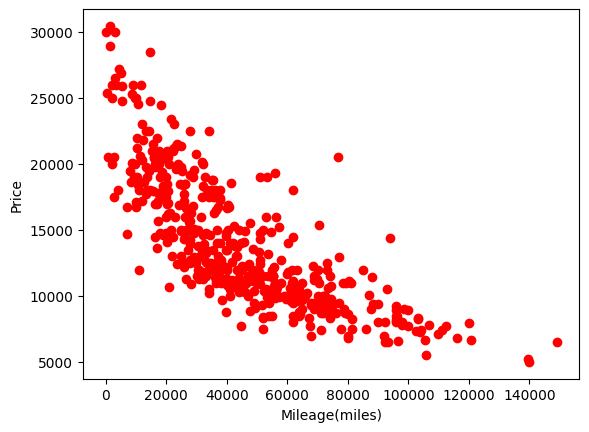

In [236]:
plt.scatter(df['Mileage(miles)'], df['Price(£)'], color='r')
plt.xlabel("Mileage(miles)")
plt.ylabel("Price")
plt.show()

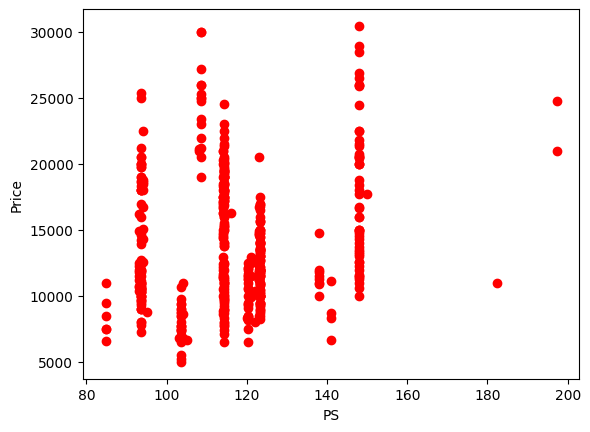

In [237]:
plt.scatter(df['PS'], df['Price(£)'], color='r')
plt.xlabel("PS")
plt.ylabel("Price")
plt.show()

In [238]:
df.columns

Index(['Year', 'Mileage(miles)', 'Engine', 'PS', 'Number_of_Owners',
       'Price(£)', 'Yas', 'Transmission_Manual', 'Fuel_Petrol'],
      dtype='object')

In [239]:
#dependent and independent features
X=df[["Mileage(miles)",'Engine', 'PS', 'Number_of_Owners','Yas', 'Transmission_Manual', 'Fuel_Petrol']]
#X=df.drop(["Price(£)","Year",axis=1])
y=df['Price(£)']

In [240]:
X.head()

,Mileage(miles),Engine,PS,Number_of_Owners,Yas,Transmission_Manual,Fuel_Petrol
0,44000.0,1.6,114.398422,1,8,1,0
1,42596.0,1.0,93.688363,3,10,1,1
2,42700.0,1.4,123.274162,2,11,1,1
3,86000.0,1.6,103.550296,3,12,1,0
4,104310.0,1.6,103.550296,3,12,1,0


In [241]:
y.head()

,Price(£)
0,14995.0
1,10755.0
2,10799.0
3,7490.0
4,7400.0


In [242]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25, random_state=42)

In [243]:
X_train

,Mileage(miles),Engine,PS,Number_of_Owners,Yas,Transmission_Manual,Fuel_Petrol
94,69900.0,1.4,148.000000,1,10,1,1
287,52100.0,1.4,120.315582,1,12,1,1
369,13730.0,1.0,114.398422,1,7,1,1
324,33126.0,1.4,123.274162,3,9,1,1
314,96000.0,1.0,93.688363,2,10,1,1
...,...,...,...,...,...,...,...
106,40465.0,1.0,114.000000,1,7,1,1
270,39792.0,1.4,147.928994,2,10,0,1
348,25789.0,1.5,150.000000,3,7,1,1
435,13320.0,1.0,114.398422,1,6,0,1


In [244]:
y_test

,Price(£)
55,13470.0
73,10345.0
33,15495.0
446,13500.0
425,16985.0
...,...
84,8300.0
323,11990.0
262,24990.0
199,16689.0


In [245]:
scaler = StandardScaler()

In [246]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [247]:
#Lineer Regresyon

Mean Absulate Error: 1225.8505438628033
Mean Squared Error: 2293650.1848551994
r2 score: 0.8943609856062928


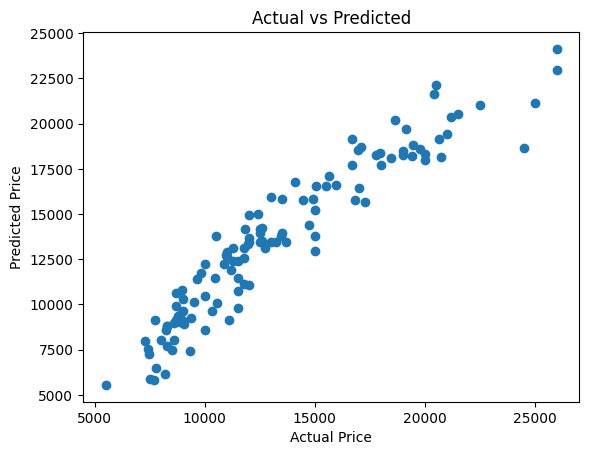

In [248]:
regression = LinearRegression()
regression.fit(X_train_scaled,y_train)
y_pred = regression.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absulate Error:", mae)
print("Mean Squared Error:", mse)
print("r2 score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

Mean Absulate Error: 1225.9410178942414
Mean Squared Error: 2295084.979230965
r2 score: 0.894294903051632


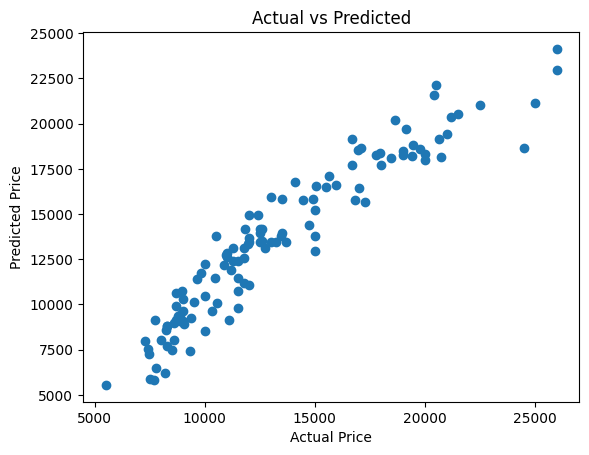

In [249]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absulate Error:", mae)
print("Mean Squared Error:", mse)
print("r2 score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

Mean Absulate Error: 1227.2924979796596
Mean Squared Error: 2297836.2406923375
r2 score: 0.8941681877612891


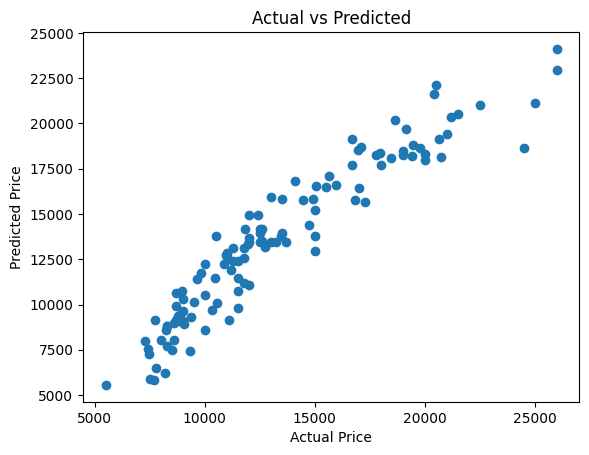

In [250]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absulate Error:", mae)
print("Mean Squared Error:", mse)
print("r2 score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

Mean Absulate Error: 1557.8363363266205
Mean Squared Error: 3584824.889229409
r2 score: 0.8348931451828462


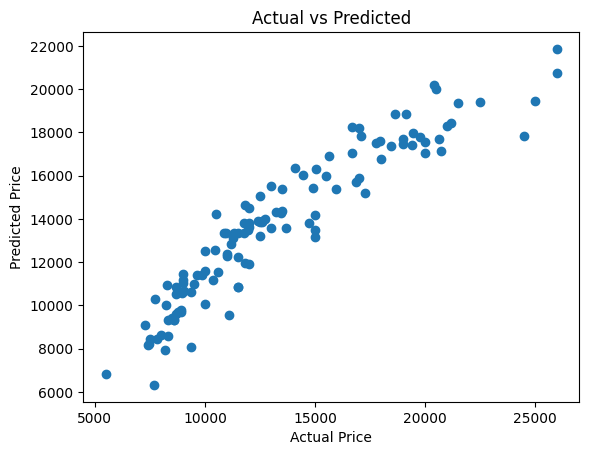

In [251]:
from sklearn.linear_model import ElasticNet
elastic = ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred = elastic.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absulate Error:", mae)
print("Mean Squared Error:", mse)
print("r2 score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

Mean Absulate Error: 1229.1250654446
Mean Squared Error: 2328000.8130123676
r2 score: 0.8927788932164905


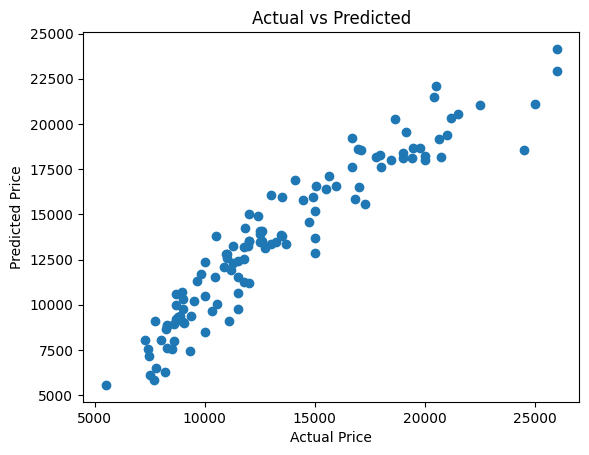

In [256]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=10)
lassocv.fit(X_train_scaled,y_train)
y_pred = lassocv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absulate Error:", mae)
print("Mean Squared Error:", mse)
print("r2 score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [258]:
lassocv.alpha_ # hangi alfa değerinde hesaplama yaptı.

np.float64(15.75867003095017)

Mean Absulate Error: 1225.8505438628033
Mean Squared Error: 2293650.1848551994
r2 score: 0.8943609856062928


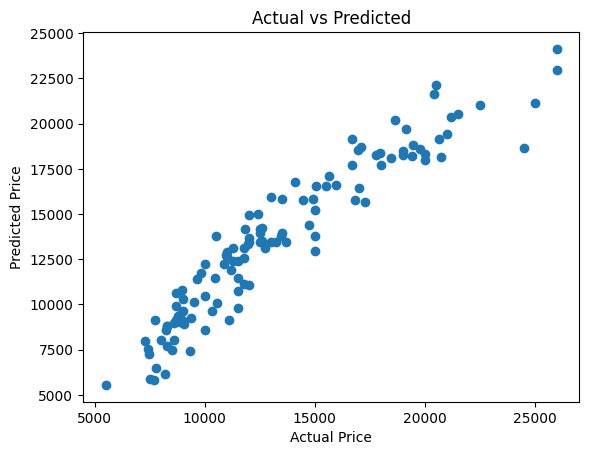

In [259]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
regression = LinearRegression()
regression.fit(X_train_scaled,y_train)
y_pred = regression.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absulate Error:", mae)
print("Mean Squared Error:", mse)
print("r2 score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()